# 실습 프로젝트 : 의사결정트리 정확도 향상

## 실습 목표
현재 생성된 Decision Tree 모델의 성능을 분석하고 다양한 방법으로 정확도를 향상시켜 본다.

## 문제 1. 현재 모델 성능 분석

Accuracy, Precision, Recall, F1-score, Confusion Matrix를 출력하시오.

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# [SH] 라이브러리 추가 start
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
# [SH] 라이브러리 추가 end

# [SH] 데이터 로드 및 전처리 start
url = "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/credit.csv"
df = pd.read_csv(url)
# print(df.shape)
# df.head()

df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
# df_encoded.head()
# [SH] 데이터 로드 및 전처리 end

#[SH] 데이터분리 Start
X, y = df_encoded.drop('default', axis=1), df_encoded['default']
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# print(X_train.shape, X_test.shape)
#[SH] 데이터분리 End
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# [SH] 모델 학습 start


acc = accuracy_score(y_test, predictions)
prec = precision_score(y_test, predictions, average='weighted')
rec = recall_score(y_test, predictions, average='weighted')
f1 = f1_score(y_test, predictions, average='weighted')

print('Accuracy :', acc)
print('Precision :', prec)
print('Recall :', rec)
print('F1 :', f1)
print(confusion_matrix(y_test, predictions))

Accuracy : 0.705
Precision : 0.7093152589502956
Recall : 0.705
F1 : 0.707000088051422
[[109  31]
 [ 28  32]]


### 질문

1. Accuracy의 의미는?:정확도. 모델이 얼마나 예측을 잘했는지
2. Precision과 Recall 차이는? precision은 실제로 맞은것, recall은 모델이 실제로 예측한것
3. 은행 대출 심사에서는 Recall이 중요한 이유는? 상환못할 고객을 찾아내야하기때문에 예측이 중요하지않을까

## 문제 2 ~ 8

각 문제에 대해 코드 실행 후 결과표와 답안을 작성하시오.

In [51]:
#  문제 2. max_depth 튜닝 ============================
# 다음 값을 적용하여 정확도를 비교하시오.
# max_depth = 3
# max_depth = 5
# max_depth = 7
# max_depth = 10
# max_depth = None
# model = DecisionTreeClassifier(
#     max_depth=5,
#     random_state=42
# )

depth_list = [3,5,7,10,None]
results = []
for depth in depth_list:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([str(depth),acc])
print(results)

pd.DataFrame(results, columns=['max_depth','accuracy'])

### 질문 ----------------------------------------------------------------
# 깊이가 너무 크면 어떤 문제가 발생하는가? 답을 적으시오.
# 깊이가 너무 크니까 오히려 정확도가 낮다. 트리가 너무 복잡해져서 과적합이 발생했을수도있겠다. 

[['3', 0.735], ['5', 0.745], ['7', 0.675], ['10', 0.66], ['None', 0.705]]


,max_depth,accuracy
0,3,0.735
1,5,0.745
2,7,0.675
3,10,0.660
4,None,0.705


In [52]:
# 문제 3. min_samples_split 실험 ====================================
# 노드를 분할하기 위한 최소 샘플 수를 변경하시오.

### 실험값
# 2
# 5
# 10
# 20
# 50
split_values = [2,5,10,20,50]
results = []

### 코드
# DecisionTreeClassifier(
#     min_samples_split=10
# )
for split in split_values:
    model = DecisionTreeClassifier(
        min_samples_split=split,
        random_state=42
    )
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([split,acc])
### 결과표를 작성하시오.
# | min_samples_split | Accuracy |
# | --------------- | -------- |
# | 2                 |         
# | 5                 |         
# | 10               |         
# | 20               |         
# | 50               |          

pd.DataFrame(
    results,
    columns=['min_samples_split','Accuracy']
)


### 질문 -------------------------------------------------
# 값이 커질수록 트리는 어떻게 변하는가? (답안을 작성하시오.)
'''
값이 커질수록 정확도가 올라가는듯하다. 
min_samples_split이 뭔지 찾아보니까.. 노드를 더 쪼개기 위해 필요한 최소 데이터수이다.
결국 브레이크 역할을 하니까 숫자가 작을수록 복잡한 트리가 될거고 숫자가 클수록 단순한 트리가 되는데
그러다보니까 과적합을 방지하는 효과가 있어서 그런것같다.
'''

'\n값이 커질수록 정확도가 올라가는듯하다. \nmin_samples_split이 뭔지 찾아보니까.. 노드를 더 쪼개기 위해 필요한 최소 데이터수이다.\n결국 브레이크 역할을 하니까 숫자가 작을수록 복잡한 트리가 될거고 숫자가 클수록 단순한 트리가 되는데\n그러다보니까 과적합을 방지하는 효과가 있어서 그런것같다.\n'

In [53]:
# 문제 4. min_samples_leaf 실험 ======================================
# 다음 값을 적용하여 비교하시오.
# 1
# 5
# 10
# 20
# 30
leaf_values = [1,5,10,20,30]
results = []

### 코드
# DecisionTreeClassifier(
#     min_samples_leaf=10
# )
for leaf in leaf_values:
    model = DecisionTreeClassifier(
        min_samples_leaf=leaf,
        random_state=42
    )
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([leaf,acc])

### 결과표를 작성하시오.
# | Leaf | Accuracy |
# | ---- | -------------- |
# | 1    |       
# | 5    |          
# | 10   |         
# | 20   |         
# | 30   |         
pd.DataFrame(
    results,
    columns=['Leaf','Accuracy']
)

### 질문
# Leaf 크기를 크게 하는 목적은? (답안을 작성하시오.)
'''
leaf크기가 커지니까 정확도가 올라가고있다. leaf이 뭔지 또 기억이 안나서 찾아보니..
leaf는 마지막 노드이고 리프가 커지면 트리가 단순화된다. 
결국 앞서 살펴본 depth, min_samples_split과 똑같은 이론이다.
트리 단순화 = 과접합 방지일듯하다.
'''

'\nleaf크기가 커지니까 정확도가 올라가고있다. leaf이 뭔지 또 기억이 안나서 찾아보니..\nleaf는 마지막 노드이고 리프가 커지면 트리가 단순화된다. \n결국 앞서 살펴본 depth, min_samples_split과 똑같은 이론이다.\n트리 단순화 = 과접합 방지일듯하다.\n'

In [54]:
# 문제 5. Criterion 변경 ===============================================
# 다음 두 가지를 비교하시오.
# criterion='gini'
# criterion='entropy'
criteria = ['gini','entropy']
results = []

## 코드
# DecisionTreeClassifier(
#     criterion='entropy'
# )
for criterion in criteria:
    model = DecisionTreeClassifier(
        criterion=criterion,
        random_state=42
    )
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    acc = accuracy_score(y_test,pred)
    results.append([criterion,acc])

### 결과표를 작성하시오.
# | Criterion | Accuracy |
# | ----------- | ------------ |
# | gini      |         
# | entropy   |     
pd.DataFrame(
    results,
    columns=['Criterion','Accuracy']
)     

## 질문 ------------------------------------------------
# Entropy와 Gini 차이는?
'''
우선 gini는 entropy보다 좀 더 정확도가 높았다.
두개가 뭔지 몰라서 또 찾아봄..
criterion은 어떤 기준으로 데이터를 가장 잘 나눌지를 결정하는 함수인데
gini는 각 클래스의 비율로, entropy는 정보이론? 기반을 사용해서 gini보다 좀더 느린 이론적으로 엄밀한 기준을 말한다고한다.
그래서 entroy가 좀더 정확도가 낮은 듯하다. 실무에서는 아무래도 entroy 가 많이 쓰이겠다.  
''' 

'\n우선 gini는 entropy보다 좀 더 정확도가 높았다.\n두개가 뭔지 몰라서 또 찾아봄..\ncriterion은 어떤 기준으로 데이터를 가장 잘 나눌지를 결정하는 함수인데\ngini는 각 클래스의 비율로, entropy는 정보이론? 기반을 사용해서 gini보다 좀더 느린 이론적으로 엄밀한 기준을 말한다고한다.\n그래서 entroy가 좀더 정확도가 낮은 듯하다. 실무에서는 아무래도 entroy 가 많이 쓰이겠다.  \n'

In [55]:
# 문제 6. Feature Importance 분석
# 가장 중요한 변수를 찾아라.
'''
우선 feature importance가 뭔지 찾아보니 의사결정트리가 각 변수를 얼마나 자주 사용했는지를 점수로 나타내는 것이라고한다. 
즉 어떤 변수가 트리를 잘 나누는데 많이 기여했는지를 나타내는 지표인듯하다.
'''

### 코드
# importance = model.feature_importances_
# for feature, score in zip(
#     feature_names,
#     importance
# ):
    # print(feature, score)
model = DecisionTreeClassifier(
    random_state=42
)
model.fit(X_train,y_train)

importance = model.feature_importances_
for feature, score in zip(
    feature_names,
    importance
):

### 출력 예
# checking_balance     0.41
# credit_amount        0.25
# duration             0.17
# ...
    print(feature, score)

### 질문 -----------------------------------------------
# 가장 중요한 변수는 무엇인가?
'''
checkiing balance 가 중요한듯하다 
왜인지가 궁금해서 찾아보니 checking_balance는 잔액값이다. 
현재 돈이 있는지 없는지가 아무래도 credit에 가장 큰 영향을 미치는듯하다. 생각해보니 당연한 얘기같다.
''' 

checking_balance 0.15690552052298942
months_loan_duration 0.08005074756375154
credit_history 0.0660932397449784
purpose 0.0753727111039797
amount 0.13882002563279797
savings_balance 0.060913716183855056
employment_length 0.05360959027202194
installment_rate 0.019598186464807866
personal_status 0.03611085848480808
other_debtors 0.043492612077328734
residence_history 0.029808654803349207
property 0.04744404259973071
age 0.07621904536699546
installment_plan 0.02626693632726287
housing 0.016833832739444977
existing_credits 0.023515334430827393
dependents 0.009625402897828133
telephone 0.02140098888525661
foreign_worker 0.005208333333333333
job 0.012710220564652652


'\ncheckiing balance 가 중요한듯하다 \n왜인지가 궁금해서 찾아보니 checking_balance는 잔액값이다. \n현재 돈이 있는지 없는지가 아무래도 credit에 가장 큰 영향을 미치는듯하다. 생각해보니 당연한 얘기같다.\n'

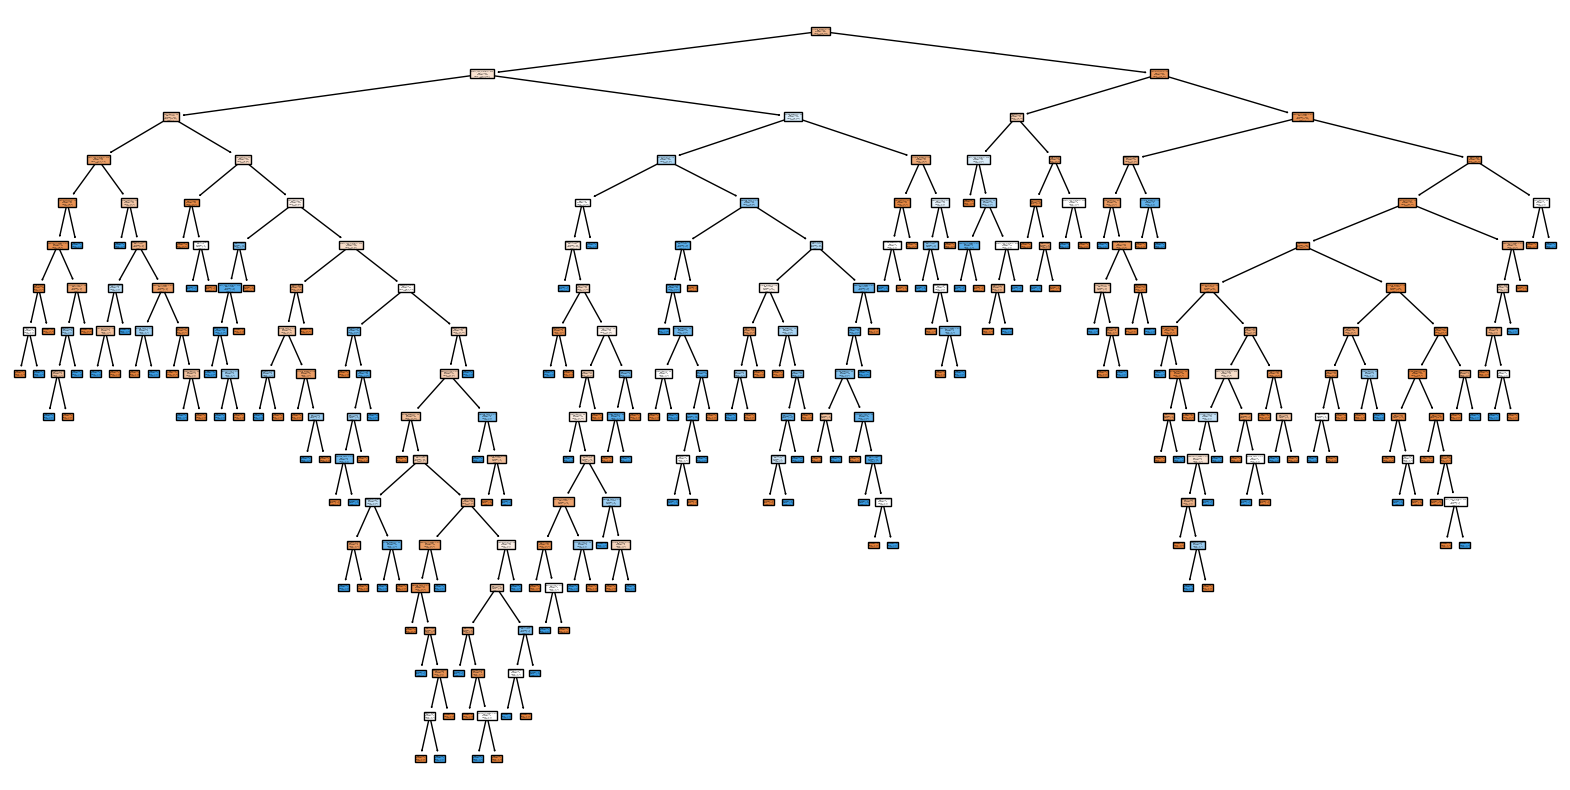

'\n루트 모드는 처음 갈라질때를 의미한다고 알고있다. \n이 모델이 가장 먼저 분류한값이니 우선순위로 판단한 기준변수인듯하다.\n'

In [56]:
# 문제 7. 트리 시각화 ====================================
# 생성된 트리를 시각화하시오.

### 코드
# from sklearn.tree import plot_tree
'''
또 검색해보니까 이때 class_names할때 model.classes를 넣어주면 
모델이 학습하면서 자동으로 알고 있는 클래스를 넣을수있다고 한다.
'''
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=feature_names,
    # class_names = ['yes', 'no'],
    class_names = model.classes_.astype(str),
    filled=True
)
plt.show()

### 질문 ----------------------------------------------------------------
# 루트 노드가 의미하는 것은?
'''
루트 모드는 처음 갈라질때를 의미한다고 알고있다. 
이 모델이 가장 먼저 분류한값이니 우선순위로 판단한 기준변수인듯하다.
''' 

In [ ]:
# 문제 8. 데이터 전처리 개선 ==========================================
# One-Hot Encoding 적용 전후 성능을 비교하시오.
'''
one hot encoding은 문자열을 숫자로 바꿔주는 방법으로 0, 1의 숫자로 변환하는 것이라고 한다.
'''

### 기존
# LabelEncoder

df_encoded = df.copy()
label_encoders = {}
for col in df_encoded.select_dtypes(include='object').columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
# df_encoded.head()
# [SH] 데이터 로드 및 전처리 end

#[SH] 데이터분리 Start
X, y = df_encoded.drop('default', axis=1), df_encoded['default']
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
# print(X_train.shape, X_test.shape)
#[SH] 데이터분리 End
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)
predictions = model.predict(X_test)
# [SH] 모델 학습 start


acc_label = accuracy_score(y_test, predictions)

### 변경
# pd.get_dummies()
# 또는
# OneHotEncoder()
df_onehot = pd.get_dummies(df)
x = df_onehot.drop('default', axis=1)
y = df_onehot['default']

X_train, X_test, y_train, y_test = train_test_split(
    x, 
    y, 
    test_size=0.2, 
    random_state=42,
    stratify=y
    )
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train,y_train)
pred = model.predict(X_test)
acc_onehot = accuracy_score(y_test, pred)

### 결과표
# | Encoding             | Accuracy |
# | ---------------------- | -------- 
# | LabelEncoder     |          
# | OneHotEncoder |     
results = [
    ['LabelEncoder', acc_label],
    ['OneHotEncoder', acc_onehot]
]
pd.DataFrame(results, columns=['Encoding', 'Accuracy'])

### 질문 -------------------------------------------------
# One-Hot Encoding이 유리한 이유는?
'''
내가 한것에서는 label이 0.7, onehotencoder가 0.5이 나왔는데 왜 그런걸까?
우선 onehot은 변수의 순서를 제거해 변수를 하나의 벡터로 만들어준다.
label은 변수의 순서를 만들어주는데 이게 트리에서는 오히려 혼란을 줄수도 있을듯하다.
그래서 onehot이 좀더 정확도가 낮게 나오긴했는데 정확도는 높을 수록 좋지만 
우선 일반화/데이터해석 안정성 기준으로는 더 유리하지않을까..
''' 


,Encoding,Accuracy
0,LabelEncoder,0.705
1,OneHotEncoder,0.590
